# Animal Sleep

Some animals, such as elephants, sleep only 3-4 hours a night, while others, like bats, can sleep up to 20 hours.

Is there a relationship between sleep duration and body mass? Is a species' diet correlated with sleep time?

The file `animal-sleep.csv` provides data on the average sleep duration of 77 animal species, along with their average body mass in kilograms.

In [8]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'animal-sleep.csv' and 'linear_model.py'.

# from google.colab import files
# uploaded = files.upload()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('animal-sleep.csv')
df.head()

,animal,diet,sleep,mass
0,african elephant,herbivore,3.3,6654.000
1,african giant pouched rat,omnivore,8.3,1.000
2,african striped mouse,herbivore,8.7,0.044
3,arctic fox,carnivore,12.5,3.380
4,arctic ground squirrel,omnivore,16.6,0.920


Text(0, 0.5, 'hours of sleep per day')

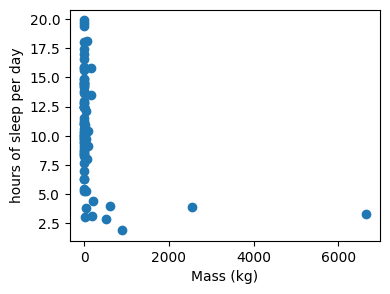

In [10]:
plt.figure(figsize=(4, 3))
plt.scatter(df['mass'], df['sleep'])
plt.xlabel('Mass (kg)')
plt.ylabel('hours of sleep per day')

We see that the mass data exhibits a strong right skew with a long tail. A log transformation can convert an exponential relationship into a linear one, making it easier to model with linear regression.

In [11]:
import math
df['log10_mass'] = df['mass'].apply(math.log10)  # apply the function to each element
df.head()

,animal,diet,sleep,mass,log10_mass
0,african elephant,herbivore,3.3,6654.000,3.823083
1,african giant pouched rat,omnivore,8.3,1.000,0.000000
2,african striped mouse,herbivore,8.7,0.044,-1.356547
3,arctic fox,carnivore,12.5,3.380,0.528917
4,arctic ground squirrel,omnivore,16.6,0.920,-0.036212


Below is code for plotting the data using the log scale.

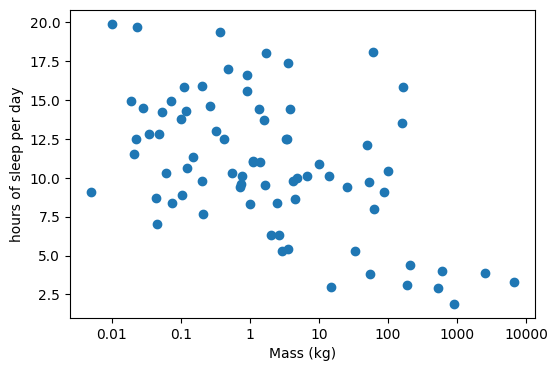

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(df['log10_mass'], df['sleep'])
plt.xlabel('Mass (kg)')
plt.ylabel('hours of sleep per day')
xticks = [-2, -1, 0, 1, 2, 3, 4]
xtick_labels = [0.01, 0.1, 1, 10, 100, 1000, 10000]
plt.xticks(xticks, xtick_labels)
plt.show()

### Project Ideas

- Model the relationship between `log10_mass` and hours of `sleep`.

- Create three separate linear models for each `diet` category: carnivores, omnivores, and herbivores.

- Visualize the data and their best-fit lines on a single plot with distinct colors and symbols for each `diet` category, or use separate plots if more suitable.

- Explore and propose mechanisms that could explain the results, potentially involving additional research.

In [13]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):
#     print(f"Model: y = {self.intercept:.2f} + {self.slope:.2f} * x")


In [15]:
import linear_model

# linear = linear_model.LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info()

LinearModel():
Slope: -1.6149691733776594
Intercept: 11.217396810788516
R-squared: 0.26432361005128435


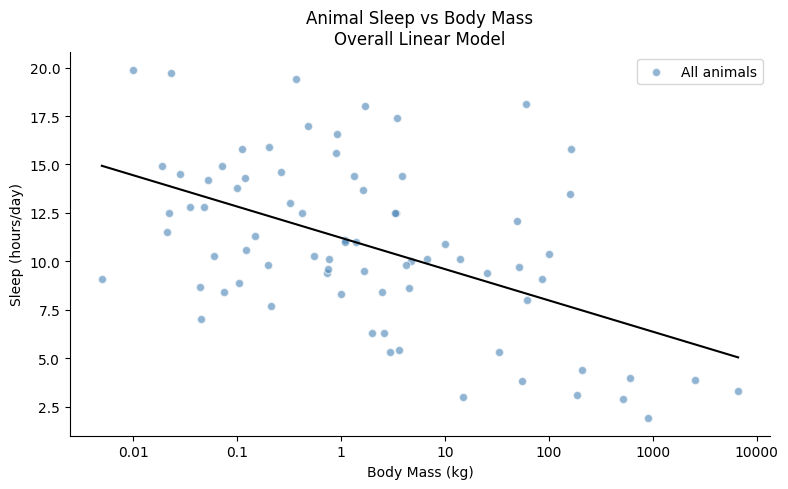

In [16]:
# ── 1. Overall linear model: log10_mass vs sleep ──────────────────────────────
linear_all = LinearModel()
linear_all.fit(df['log10_mass'], df['sleep'])
linear_all.print_model_info()

plt.figure(figsize=(8, 5))
plt.scatter(df['log10_mass'], df['sleep'], color='steelblue', alpha=0.6, edgecolors='white', label='All animals')

# Best-fit line
linear_all.plot_model(df['log10_mass'].min(), df['log10_mass'].max(), color='black')

# Fix x-axis to show actual kg values
xticks = [-2, -1, 0, 1, 2, 3, 4]
xtick_labels = [0.01, 0.1, 1, 10, 100, 1000, 10000]
plt.xticks(xticks, xtick_labels)

plt.xlabel('Body Mass (kg)')
plt.ylabel('Sleep (hours/day)')
plt.title('Animal Sleep vs Body Mass\nOverall Linear Model')
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Carnivore model:
LinearModel():
Slope: -0.14090226025203156
Intercept: 12.99704850696372
R-squared: 0.003186503413273978

Omnivore model:
LinearModel():
Slope: -1.0841960083999436
Intercept: 11.662140158348944
R-squared: 0.10944681716489979

Herbivore model:
LinearModel():
Slope: -2.2408355966298785
Intercept: 9.596484459635365
R-squared: 0.6255104280867234


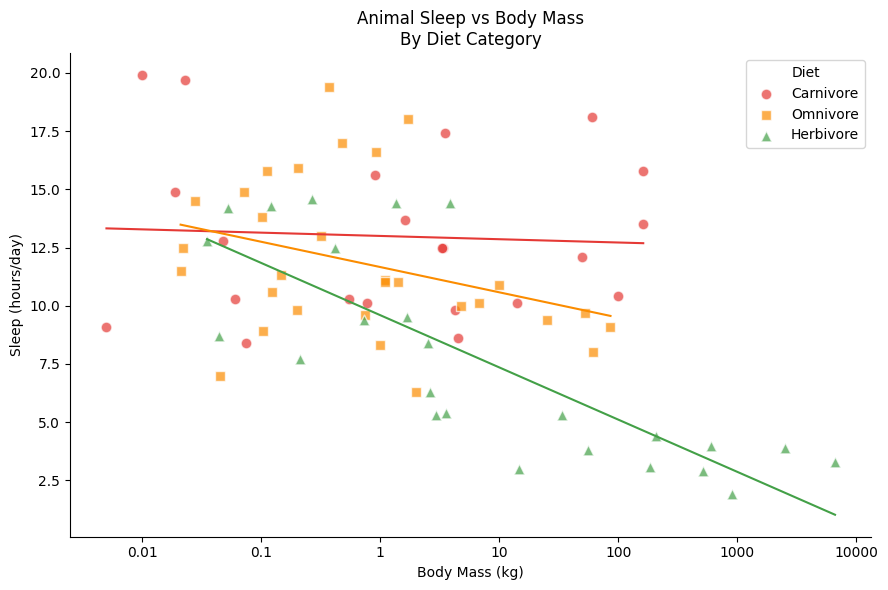

In [17]:
# ── 2. Separate linear models for each diet category ─────────────────────────
diet_styles = {
    'carnivore': {'color': '#E53935', 'marker': 'o'},
    'omnivore':  {'color': '#FB8C00', 'marker': 's'},
    'herbivore': {'color': '#43A047', 'marker': '^'}
}

plt.figure(figsize=(9, 6))

for diet, style in diet_styles.items():
    subset = df[df['diet'] == diet].dropna(subset=['log10_mass', 'sleep'])

    # Scatter points
    plt.scatter(subset['log10_mass'], subset['sleep'],
                color=style['color'], marker=style['marker'],
                alpha=0.7, edgecolors='white', label=diet.title(), s=60)

    # Fit and plot model
    model = LinearModel()
    model.fit(subset['log10_mass'], subset['sleep'])
    model.plot_model(subset['log10_mass'].min(), subset['log10_mass'].max(),
                     color=style['color'])

    print(f"\n{diet.title()} model:")
    model.print_model_info()

# Fix x-axis
xticks = [-2, -1, 0, 1, 2, 3, 4]
xtick_labels = [0.01, 0.1, 1, 10, 100, 1000, 10000]
plt.xticks(xticks, xtick_labels)

plt.xlabel('Body Mass (kg)')
plt.ylabel('Sleep (hours/day)')
plt.title('Animal Sleep vs Body Mass\nBy Diet Category')
plt.legend(title='Diet')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

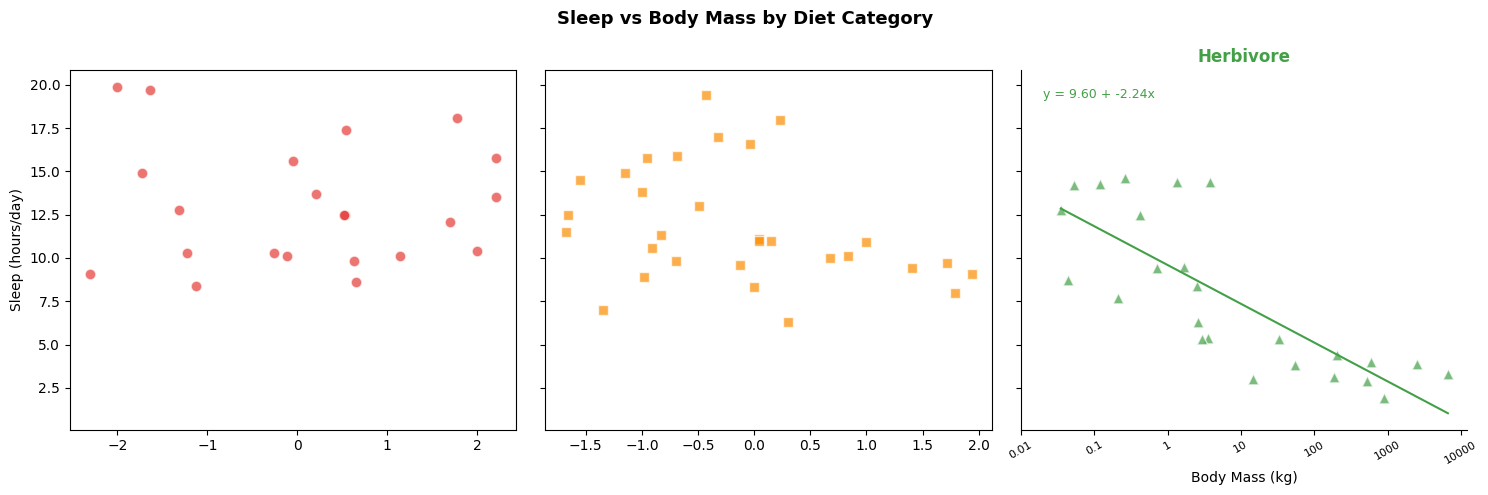

In [24]:
# ── 3. Separate subplots per diet (cleaner alternative view) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (diet, style) in zip(axes, diet_styles.items()):
    subset = df[df['diet'] == diet].dropna(subset=['log10_mass', 'sleep'])

    ax.scatter(subset['log10_mass'], subset['sleep'],
               color=style['color'], marker=style['marker'],
               alpha=0.7, edgecolors='white', s=60)

    model = LinearModel()
    model.fit(subset['log10_mass'], subset['sleep'])

    x_range = [subset['log10_mass'].min(), subset['log10_mass'].max()]
# instead of manually calling predict, use the built-in method
model.plot_model(subset['log10_mass'].min(), subset['log10_mass'].max(), color=style['color'])
# ax.plot(x_range, y_pred, color=style['color'], linewidth=2)

    # Annotate with model equation
info = f"y = {model.intercept:.2f} + {model.slope:.2f}x"
ax.text(0.05, 0.95, info, transform=ax.transAxes,
        fontsize=9, va='top', color=style['color'])
ax.set_xticks([-2, -1, 0, 1, 2, 3, 4])
ax.set_xticklabels([0.01, 0.1, 1, 10, 100, 1000, 10000], rotation=30, fontsize=8)
ax.set_title(diet.title(), fontweight='bold', color=style['color'])
ax.set_xlabel('Body Mass (kg)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Sleep (hours/day)')
fig.suptitle('Sleep vs Body Mass by Diet Category', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# ── 4. Summary: Average sleep per diet group ──────────────────────────────────
print("Average Sleep by Diet Category")
print("=" * 40)
summary = df.groupby('diet')['sleep'].agg(['mean', 'min', 'max', 'count'])
summary.columns = ['Avg Sleep (hrs)', 'Min', 'Max', 'Count']
print(summary.round(2))

Average Sleep by Diet Category
           Avg Sleep (hrs)  Min   Max  Count
diet                                        
carnivore            12.98  8.4  19.9     22
herbivore             7.74  1.9  14.6     25
omnivore             11.83  6.3  19.4     30
